### Problem 1
#### Gambler's Ruin With Retirement

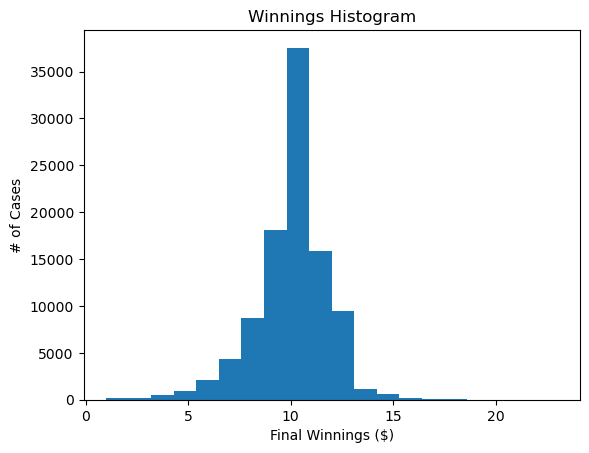

Expected Final Value from Simulation: $9.79571
Expected final Value from Analytical Solution: $7.400132482594408


In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Givens
q = 0.4
p = 0.35
s = 0.25

i0 = 10 # Starting value $

def simulate_gamblers(i0,p,q,s):
    """ 
    Simulate Gambler's ruin with retirement with 2 abosrbing states.
    """
    X = [i0]
    options = ['up','down','retire']
    weights = [p,q,s]
    while X[-1] != 0 and X[-1] != np.pi:
        action = random.choices(options,weights,k=1)
        if action[0] =='up':
            X.append(X[-1]+1)
        elif action[0] =='down':
            X.append(X[-1]-1)
        elif action[0] =='retire':
            X.append(np.pi)            
    return X

N = 100000
X_end = np.zeros(shape=[N,1])

# Iterating through each trial
for i in range(N):
    X = simulate_gamblers(i0,p,q,s)
    X_end[i] = X[-2]

# Plotting results
plt.hist(X_end, bins=20,histtype='stepfilled',)
plt.title('Winnings Histogram')
plt.xlabel('Final Winnings ($)')
plt.ylabel('# of Cases')
plt.show()

print(f'Expected Final Value from Simulation: ${np.mean(X_end)}')

# Analytical solution
r1 = (1 - np.sqrt(1-4*p*q))/(2*p)
E = lambda i:(q-p)/s*r1**i + i + (p-1)/s
print(f'Expected final Value from Analytical Solution: ${E(i0)}')
